# XGBoost para regresión de consumo eléctrico

## Objetivos de aprendizaje

Al finalizar este laboratorio podrás:

- describir cómo XGBoost construye árboles de forma aditiva y secuencial;
- interpretar learning rate, número/profundidad de árboles y regularización;
- seleccionar hiperparámetros con GridSearchCV y TimeSeriesSplit, dejando test reservado;
- comparar XGBoost con DummyRegressor y una referencia lineal.

## Problema y datos

El objetivo es estimar `Consumption` en observaciones horarias del CSV eléctrico mediante variables de generación y calendario. Como se incluyen variables contemporáneas de producción, el problema es una estimación condicionada, no un pronóstico futuro operativo si esos valores no se conocen para el horizonte.

Las filas se ordenan y se dividen cronológicamente en train, validation y test. La búsqueda en train conserva el grid original y emplea folds temporales; el test se utiliza una sola vez para evaluar la configuración seleccionada.

In [ ]:
# XGBoost, baseline, metricas y utilidades del proyecto
from xgboost import XGBRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from ml_course.data import get_data_path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Construimos una ruta reproducible al archivo fuente compartido
from ml_course.data import get_data_path

csv_path = get_data_path("electricity_consumption_and_production.csv", category="external")
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [ ]:
# Variables energeticas candidatas; la correlacion con Consumption se calculara solo en train.
candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass',
]
print('Variables energeticas candidatas:', candidate_cols)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


In [ ]:
# Funcion para generar variables temporales a partir del indice de fechas
def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour'] = out.index.hour
    out['day_of_week'] = out.index.day_of_week
    out['month'] = out.index.month
    out['quarter'] = out.index.quarter
    out['year'] = out.index.year
    out['day_of_year'] = out.index.dayofyear
    return out

feat_df = create_time_features(raw)
energy_candidate_features = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass',
]
categorical_time_features = ['hour', 'day_of_week', 'month', 'quarter', 'year']
numeric_features = energy_candidate_features + ['day_of_year']
TARGET = 'Consumption'
model_df = feat_df[['Consumption'] + numeric_features + categorical_time_features].copy()
print('Ingenieria temporal completada; OneHotEncoder se ajustara con train.')

Ingenieria completada.
Total de features para el modelo: 59
Primeras 10 features: ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'day_of_year', 'hour_1']


In [ ]:
# Particion temporal cronologica: train 70%, validation 15%, test 15%.
model_df = model_df.sort_index()
n_rows = len(model_df)
train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)
train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:validation_end].copy()
test_df = model_df.iloc[validation_end:].copy()

corr_with_target = train_df[['Consumption'] + candidate_cols].corr(numeric_only=True)['Consumption']
corr_with_target = corr_with_target.drop('Consumption').sort_values(key=np.abs, ascending=False)
display(corr_with_target.to_frame('corr_vs_consumption_train'))

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoder.fit(train_df[categorical_time_features])
encoded_columns = encoder.get_feature_names_out(categorical_time_features)

def encode_calendar_features(partition):
    encoded = encoder.transform(partition[categorical_time_features])
    encoded_frame = pd.DataFrame(encoded, columns=encoded_columns, index=partition.index)
    return pd.concat([partition.drop(columns=categorical_time_features), encoded_frame], axis=1)

train_df = encode_calendar_features(train_df)
val_df = encode_calendar_features(val_df)
test_df = encode_calendar_features(test_df)
FEATURES = [column for column in train_df.columns if column != TARGET]
model_df = pd.concat([train_df, val_df, test_df]).sort_index()

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print('Train:', train_df.index.min(), '->', train_df.index.max(), X_train.shape)
print('Validation:', val_df.index.min(), '->', val_df.index.max(), X_val.shape)
print('Test:', test_df.index.min(), '->', test_df.index.max(), X_test.shape)
print('No se aplica escalado: XGBoost divide por umbrales de feature.')

Train size: (43967, 59)
Validation size: (9421, 59)
Test size: (9422, 59)
Random state usado: 42
Escalado aplicado: no, porque el modelo es un arbol de regresion.


In [ ]:
# Ajustamos DummyRegressor y XGBoost con parametros base.
dummy_model = DummyRegressor(strategy='mean').fit(X_train, y_train)
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='rmse',
    n_jobs=-1,
    random_state=42,
)
xgb_model.fit(X_train, y_train)

predictions = {
    'DummyRegressor (media)': (dummy_model.predict(X_val), dummy_model.predict(X_test)),
    'XGBRegressor': (xgb_model.predict(X_val), xgb_model.predict(X_test)),
}
pred_val, pred_xgb = predictions['XGBRegressor']

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    if not np.any(nonzero):
        return float('nan')
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

results = pd.DataFrame([
    {
        'split': split_name,
        'modelo': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAPE_%': mape(y_true, y_pred),
    }
    for split_name, y_true, prediction_index in [
        ('validation', y_val, 0),
        ('test', y_test, 1),
    ]
    for model_name, model_prediction in predictions.items()
    for y_pred in [model_prediction[prediction_index]]
]).set_index(['split', 'modelo'])

feature_importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': xgb_model.feature_importances_,
}).sort_values('importance', ascending=False)

print('Metricas del baseline y XGBoost:')
display(results.round(4))
print('Top 12 features por importancia:')
display(feature_importance_df.head(12))

Parametros de XGBoost:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'rmse', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}
Top 12 features por importancia:


,feature,importance
0,Production,0.112222
11,hour_3,0.060423
10,hour_2,0.059768
49,quarter_2,0.055660
12,hour_4,0.054820
29,hour_21,0.047392
28,hour_20,0.046106
27,hour_19,0.044463
9,hour_1,0.043422
13,hour_5,0.036511


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,XGBRegressor,201.9537,265.2373,0.9376,3.1958
test,XGBRegressor,202.5586,266.6545,0.9376,3.2077


Resumen de error en test:
       error_xgb  abs_error
count   9422.000   9422.000
mean      -2.019    202.559
std      266.661    173.430
min    -1292.949      0.014
25%     -162.674     74.551
50%        2.031    159.253
75%      156.323    281.709
max     1926.739   1926.739


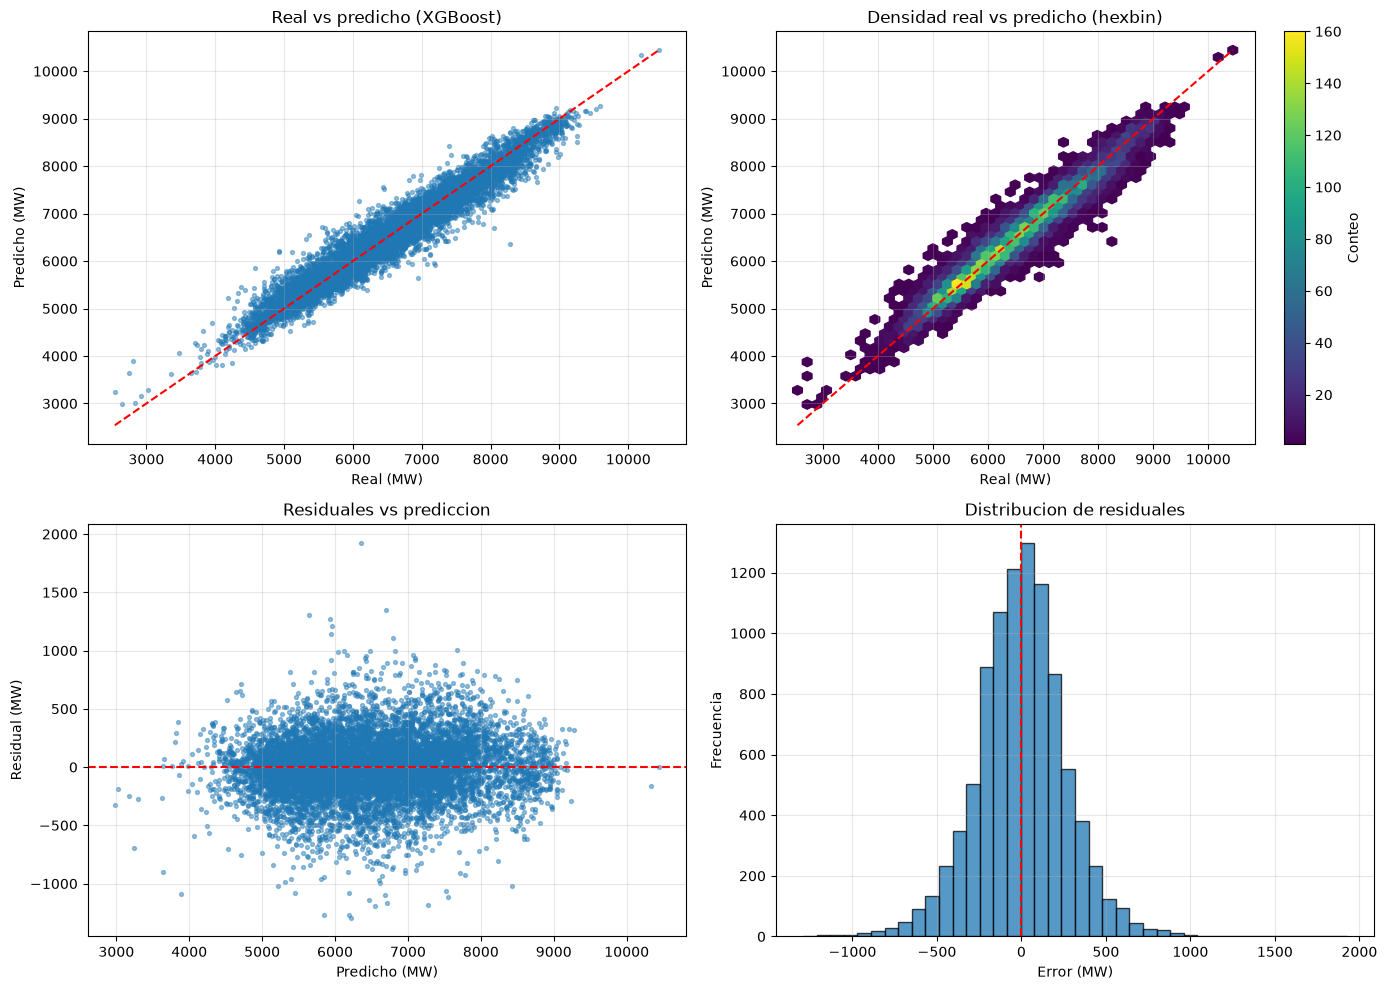

In [7]:
# Analisis de predicciones para split aleatorio (sin orden temporal)
pred_df = pd.DataFrame(index=y_test.index)
pred_df['Consumption'] = y_test
pred_df['pred_xgb'] = pred_xgb
pred_df['error_xgb'] = pred_df['Consumption'] - pred_df['pred_xgb']
pred_df['abs_error'] = pred_df['error_xgb'].abs()

print('Resumen de error en test:')
print(pred_df[['error_xgb', 'abs_error']].describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Parity plot: real vs predicho
axes[0, 0].scatter(pred_df['Consumption'], pred_df['pred_xgb'], s=8, alpha=0.45)
min_v = min(pred_df['Consumption'].min(), pred_df['pred_xgb'].min())
max_v = max(pred_df['Consumption'].max(), pred_df['pred_xgb'].max())
axes[0, 0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 0].set_title('Real vs predicho (XGBoost)')
axes[0, 0].set_xlabel('Real (MW)')
axes[0, 0].set_ylabel('Predicho (MW)')
axes[0, 0].grid(alpha=0.3)

# 2) Hexbin para densidad de puntos
hb = axes[0, 1].hexbin(
    pred_df['Consumption'],
    pred_df['pred_xgb'],
    gridsize=45,
    cmap='viridis',
    mincnt=1
)
axes[0, 1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 1].set_title('Densidad real vs predicho (hexbin)')
axes[0, 1].set_xlabel('Real (MW)')
axes[0, 1].set_ylabel('Predicho (MW)')
axes[0, 1].grid(alpha=0.3)
fig.colorbar(hb, ax=axes[0, 1], label='Conteo')

# 3) Residuales vs prediccion
axes[1, 0].scatter(pred_df['pred_xgb'], pred_df['error_xgb'], s=8, alpha=0.45)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('Predicho (MW)')
axes[1, 0].set_ylabel('Residual (MW)')
axes[1, 0].grid(alpha=0.3)

# 4) Histograma de residuales
axes[1, 1].hist(pred_df['error_xgb'], bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('Distribucion de residuales')
axes[1, 1].set_xlabel('Error (MW)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Regresión lineal de referencia

Se conserva LinearRegression como referencia sencilla para la comparación predictiva. Sus coeficientes describen asociaciones condicionadas a la codificación y la escala; no son importancias de XGBoost ni efectos causales. Compara su error en las mismas particiones temporales.

## Ajuste de XGBoost

GridSearchCV explora el espacio de `n_estimators`, `learning_rate`, profundidad, `min_child_weight`, `subsample` y `colsample_bytree` usando TimeSeriesSplit dentro de train. Examina tanto el RMSE medio como su variación entre folds: árboles más profundos no garantizan mejor generalización.

In [ ]:
# GridSearchCV temporal para XGBoost.
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

cv_xgb = TimeSeriesSplit(n_splits=3)
param_grid_xgb = {
    'n_estimators': [200, 300],
    'learning_rate': [0.03, 0.05],
    'max_depth': [4, 6],
    'min_child_weight': [1, 3],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

xgb_search = GridSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        n_jobs=-1,
        random_state=42,
    ),
    param_grid=param_grid_xgb,
    scoring='neg_root_mean_squared_error',
    cv=cv_xgb,
    n_jobs=-1,
    refit=True,
)
xgb_search.fit(X_train, y_train)

best_xgb_params = xgb_search.best_params_
best_xgb_model = xgb_search.best_estimator_
pred_val_xgb_cv = best_xgb_model.predict(X_val)
pred_test_xgb_cv = best_xgb_model.predict(X_test)

xgb_cv_results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': 'XGBRegressor (TimeSeriesSplit)',
        'MAE': mean_absolute_error(y_val, pred_val_xgb_cv),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_xgb_cv)),
        'R2': r2_score(y_val, pred_val_xgb_cv),
        'MAPE_%': mape(y_val, pred_val_xgb_cv),
    },
    {
        'split': 'test',
        'modelo': 'XGBRegressor (TimeSeriesSplit)',
        'MAE': mean_absolute_error(y_test, pred_test_xgb_cv),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_xgb_cv)),
        'R2': r2_score(y_test, pred_test_xgb_cv),
        'MAPE_%': mape(y_test, pred_test_xgb_cv),
    },
]).set_index(['split', 'modelo'])

xgb_cv_results_df = pd.DataFrame(xgb_search.cv_results_).sort_values(
    'rank_test_score'
).head(10)

print('Mejores hiperparametros encontrados con TimeSeriesSplit:')
print(best_xgb_params)
print('\nMetricas en validation y test:')
display(xgb_cv_results.round(4))
print('\nTop 10 configuraciones por RMSE promedio en CV:')
display(
    xgb_cv_results_df[
        ['param_n_estimators', 'param_learning_rate', 'param_max_depth',
         'param_min_child_weight', 'mean_test_score', 'std_test_score', 'rank_test_score']
    ].assign(mean_RMSE=lambda df: -df['mean_test_score'])
    .drop(columns='mean_test_score')
    .round(4)
)

Mejores hiperparametros encontrados:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}

Metricas de XGBoost ajustado por validacion cruzada:


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,XGBRegressor (CV),201.9537,265.2373,0.9376,3.1958
test,XGBRegressor (CV),202.5586,266.6545,0.9376,3.2077



Top 10 configuraciones por RMSE promedio en CV:


,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,std_test_score,rank_test_score,mean_RMSE
13,300,0.05,6,1,1.1431,1,267.7180
15,300,0.05,6,3,2.0282,2,268.3763
12,200,0.05,6,1,1.0389,3,297.4602
14,200,0.05,6,3,2.3428,4,298.4962
5,300,0.03,6,1,0.6447,5,304.0602
7,300,0.03,6,3,1.2157,6,304.7165
9,300,0.05,4,1,1.1494,7,328.6039
11,300,0.05,4,3,1.8167,8,329.7669
4,200,0.03,6,1,1.2378,9,338.8476
6,200,0.03,6,3,1.0288,10,339.4138


### Importancia de variables

La importancia nativa de XGBoost resume cómo se usaron las variables en los árboles ajustados. Su definición depende del tipo de importancia que exponga la versión instalada; no representa causalidad y puede dividirse entre predictores correlacionados. Contrasta la salida calculada con las variables disponibles y el rendimiento fuera de train.

Features mas importantes de XGBoost:


,feature,importance
0,Production,0.112222
11,hour_3,0.060423
10,hour_2,0.059768
49,quarter_2,0.055660
12,hour_4,0.054820
29,hour_21,0.047392
28,hour_20,0.046106
27,hour_19,0.044463
9,hour_1,0.043422
13,hour_5,0.036511


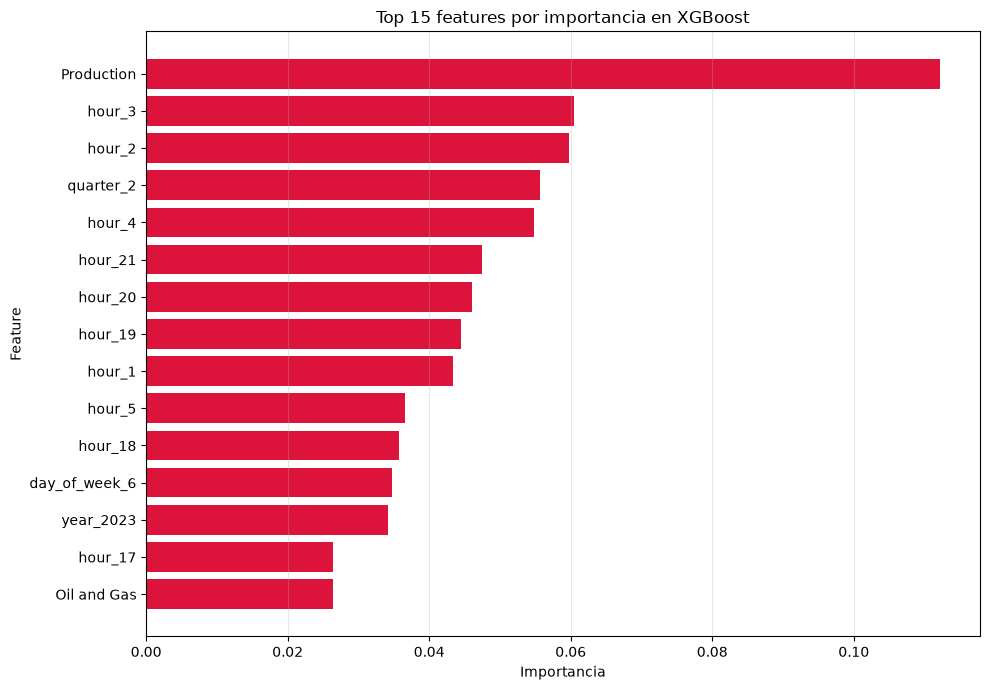

In [9]:
# Tabla y grafico de importancia de features del mejor XGBoost
feature_importance_cv_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': best_xgb_model.feature_importances_,
}).sort_values('importance', ascending=False)

print('Features mas importantes de XGBoost:')
display(feature_importance_cv_df.head(15).round(6))

importance_plot_df = feature_importance_cv_df.head(15).sort_values('importance')
plt.figure(figsize=(10, 7))
plt.barh(importance_plot_df['feature'], importance_plot_df['importance'], color='crimson')
plt.xlabel('Importancia')
plt.ylabel('Feature')
plt.title('Top 15 features por importancia en XGBoost')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Visualización de un árbol del ensamble

El gráfico muestra una estructura limitada para inspección; XGBoost combina múltiples árboles y el modelo completo no equivale a este árbol individual. Úsalo para entender umbrales locales, no como explicación completa del ensamble.

In [10]:
# Resumen de la estructura del mejor XGBoost
print('El modelo XGBoost contiene', best_xgb_model.n_estimators, 'arboles.')
print('La importancia de features y el desempeno predictivo se muestran en las celdas anteriores y siguientes.')

El modelo XGBoost contiene 300 arboles.
La importancia de features y el desempeno predictivo se muestran en las celdas anteriores y siguientes.


## Interpretación en test

Las métricas mostradas corresponden al periodo de prueba cronológico, que no participó en GridSearchCV. Compara XGBoost con DummyRegressor y LinearRegression en MAE, RMSE, R² y MAPE; interpreta el error en las unidades de consumo y considera también complejidad y estabilidad entre folds.

Hiperparametros del mejor XGBoost:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}

Metricas finales en test:


,metrica,valor
0,MAE,202.5586
1,RMSE,266.6545
2,R2,0.9376
3,MAPE_%,3.2077


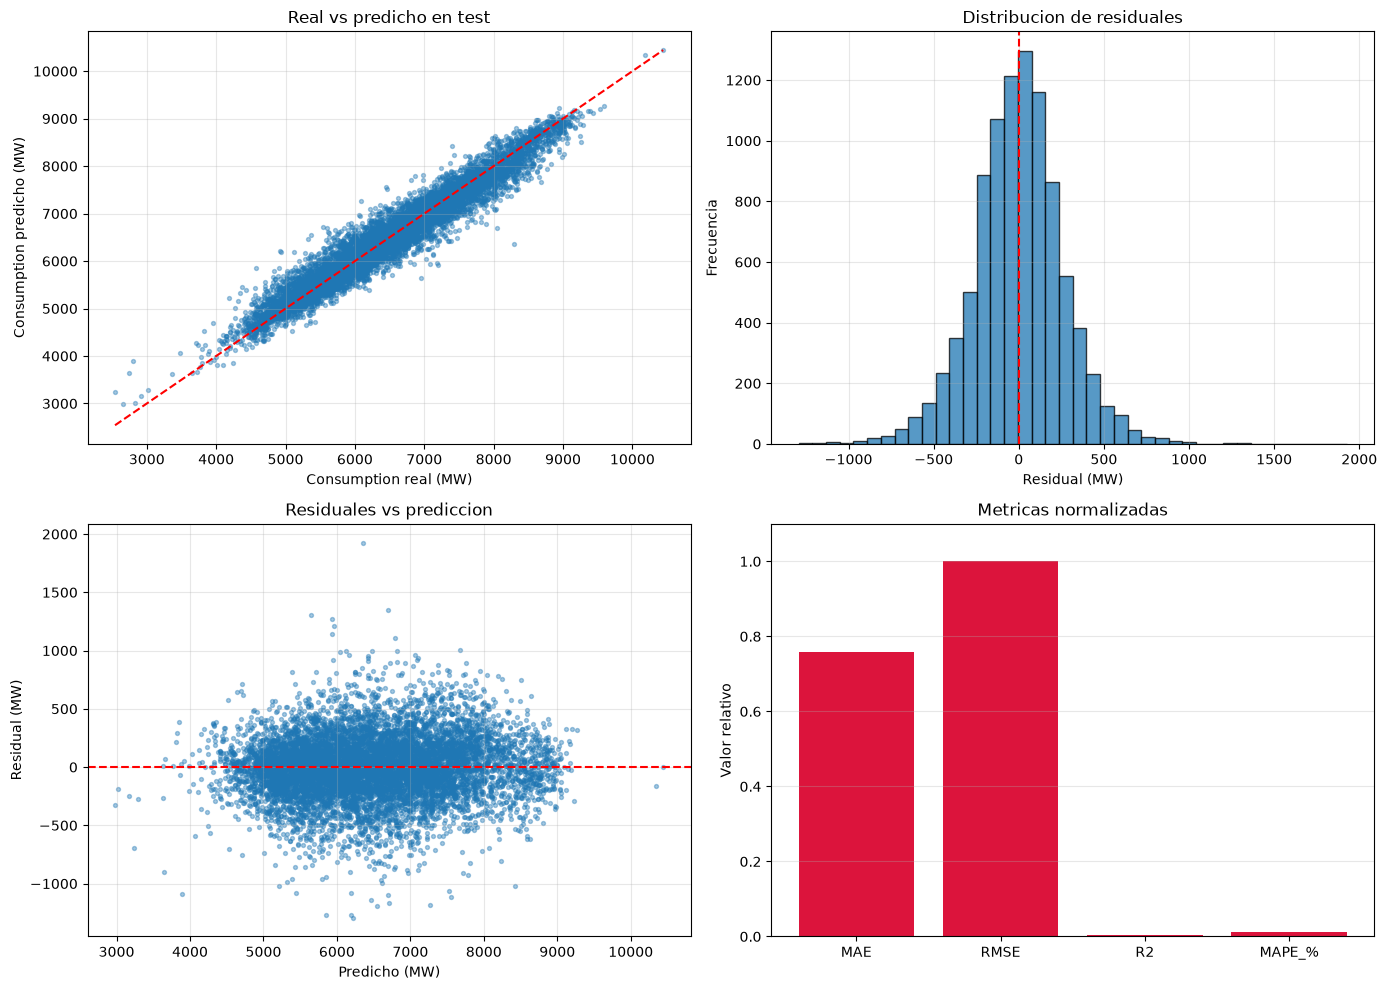

In [11]:
# Panel de desempeno predictivo del mejor XGBoost en test
if 'best_xgb_model' not in globals():
    raise NameError("Ejecuta primero la celda de validacion cruzada de XGBoost.")

best_pred_test = best_xgb_model.predict(X_test)
test_residuals = y_test.to_numpy() - best_pred_test

performance_metrics = pd.DataFrame({
    'metrica': ['MAE', 'RMSE', 'R2', 'MAPE_%'],
    'valor': [
        mean_absolute_error(y_test, best_pred_test),
        np.sqrt(mean_squared_error(y_test, best_pred_test)),
        r2_score(y_test, best_pred_test),
        mape(y_test, best_pred_test),
    ],
})

print('Hiperparametros del mejor XGBoost:')
print(best_xgb_params)
print('\nMetricas finales en test:')
display(performance_metrics.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Real vs predicho
axes[0, 0].scatter(y_test, best_pred_test, s=8, alpha=0.4)
min_value = min(y_test.min(), best_pred_test.min())
max_value = max(y_test.max(), best_pred_test.max())
axes[0, 0].plot([min_value, max_value], [min_value, max_value], 'r--', linewidth=1.5)
axes[0, 0].set_title('Real vs predicho en test')
axes[0, 0].set_xlabel('Consumption real (MW)')
axes[0, 0].set_ylabel('Consumption predicho (MW)')
axes[0, 0].grid(alpha=0.3)

# 2) Distribucion de residuales
axes[0, 1].hist(test_residuals, bins=40, edgecolor='black', alpha=0.75)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Distribucion de residuales')
axes[0, 1].set_xlabel('Residual (MW)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(alpha=0.3)

# 3) Residuales frente a la prediccion
axes[1, 0].scatter(best_pred_test, test_residuals, s=8, alpha=0.4)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('Predicho (MW)')
axes[1, 0].set_ylabel('Residual (MW)')
axes[1, 0].grid(alpha=0.3)

# 4) Barras de metricas normalizadas
metric_values = performance_metrics.set_index('metrica')['valor']
normalized_values = metric_values / metric_values.max()
axes[1, 1].bar(normalized_values.index, normalized_values.values, color='crimson')
axes[1, 1].set_title('Metricas normalizadas')
axes[1, 1].set_ylabel('Valor relativo')
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusiones

Compara XGBoost con el baseline y LinearRegression sobre el test reservado. Explica cómo se relaciona el resultado con la profundidad, el número de árboles y el learning rate seleccionados mediante CV temporal. Evalúa el error junto con la variación entre folds, el costo computacional y la disponibilidad futura de los predictores.

## Ejercicios propuestos

1. **Conceptual:** explica la función del learning rate y por qué más árboles no siempre mejoran la generalización.
2. **Implementación:** compara dos configuraciones del grid usando el mismo TimeSeriesSplit.
3. **Experimentación:** modifica `subsample` y `colsample_bytree` y describe cómo afectan la diversidad de árboles.
4. **Análisis:** compara importancias nativas con errores por periodo y discute la correlación entre fuentes energéticas.
5. **Desafío:** plantea cómo construirías un pronóstico a 24 horas si producción solo estuviera disponible hasta el instante actual.

## Referencias

- [XGBoost: documentación oficial](https://xgboost.readthedocs.io/)
- Chen, T. y Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD*. https://doi.org/10.1145/2939672.2939785
- La procedencia primaria y licencia del CSV eléctrico están pendientes de verificación; consulta [data/README.md](../../data/README.md).